In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [404]:
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [409]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [165]:
import sys
print(sys.executable)

D:\ProgramData\anaconda3\python.exe


In [167]:
import pyodbc

In [5]:
conn = pyodbc.connect(
"Driver={sql server};"
r"Server=DESKTOP-0S2L0GM\MSSQLSERVER01;"
"Database=customerchurnDB;"
"trusted_connection=yes;")

print("Database connected successfully")

Database connected successfully


In [6]:
cursor = conn.cursor()

cursor.execute("select DB_name()")
print(cursor.fetchone())

('customerchurnDB', )


In [7]:
query = "select * from customers "

df_customers = pd.read_sql_query(query,conn)

df_customers

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\3133006070.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql_query(query,conn)


,customer_id,customer_name,age,gender,city,churn
0,1001,Arun,25,Male,Bangalore,0
1,1002,Priya,32,Female,Chennai,1
2,1003,Rahul,45,Male,Hyderabad,0
3,1004,Divya,29,Female,Bangalore,1
4,1005,Karthik,38,Male,Mumbai,0
...,...,...,...,...,...,...
5005,6996,Meena,36,female,Chennai,1
5006,6997,Priya,46,female,Banglore,0
5007,6998,Arun,37,male,Banglore,1
5008,6999,Arun,46,male,Delhi,1


In [8]:
query_subscription = "Select * from subscriptions"

df_subscription = pd.read_sql_query(query_subscription, conn)
df_subscription

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\3988317151.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_subscription = pd.read_sql_query(query_subscription, conn)


,subcription_id,customer_id,plan_type,monthly_charges,tenure_months
0,1,1001,Basic,499.00,24
1,2,1002,Premium,999.00,5
2,3,1003,Standard,699.00,36
3,4,1004,Basic,499.00,7
4,5,1005,Premium,999.00,48
...,...,...,...,...,...
5005,5006,6996,Premium,1016.15,2
5006,5007,6997,Basic,450.08,60
5007,5008,6998,Basic,442.36,45
5008,5009,6999,Basic,400.23,8


In [8]:
query_payment = "select * from payments"

df_payment = pd.read_sql_query(query_payment, conn)
df_payment

C:\Users\Win10\AppData\Local\Temp\ipykernel_8888\1131659397.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_payment = pd.read_sql_query(query_payment, conn)


,payment_id,cutomer_id,payment_method
0,1,1001,UPI
1,2,1002,Credit Card
2,3,1003,UPI
3,4,1004,Debit Card
4,5,1005,Credit Card
5,6,1006,UPI
6,7,1007,Net Banking
7,8,1008,UPI
8,9,1009,Debit Card
9,10,1010,Credit Card


In [9]:
# generate 5000 customers id  

n= 5000

customer_ids = np.arange(2001, 2001+n)

customer_ids[10:]

array([2011, 2012, 2013, ..., 6998, 6999, 7000])

In [10]:
# generate customer information

np.random.seed(42)

ages = np.random.randint(18,71,n)

genders = np.random.choice (['male','female'],n)

cities = np.random.choice(['Banglore','Chennai','Hyderabad','Mumbai','Delhi'],n)



In [11]:
customers_new  = pd.DataFrame(
    {
    "customer_id":customer_ids,
    "age": ages,
    "gender":genders,
    "city":cities
    }
)

customers_new

,customer_id,age,gender,city
0,2001,56,female,Hyderabad
1,2002,69,male,Chennai
2,2003,46,female,Mumbai
3,2004,32,male,Chennai
4,2005,60,male,Delhi
...,...,...,...,...
4995,6996,36,female,Chennai
4996,6997,46,female,Banglore
4997,6998,37,male,Banglore
4998,6999,46,male,Delhi


In [12]:
#generate subscripton information
plans = np.random.choice(
    ["Basic","Standard","Premium"],
    n
    ,p=[0.4,0.35,0.25]
)

In [13]:
len(plans)

5000

In [14]:
# creating a montly plan 

monthly_charges = []

for plan in plans:
    if plan== "Basic":
        monthly_charges.append(
        np.random.uniform(399,599)
        )
    elif plan == "Standard":
        monthly_charges.append(
        np.random.uniform(599,799)
        )
    else:
        monthly_charges.append(
        np.random.uniform(799,1299)
        )

In [15]:
monthly_charges = np.round(monthly_charges,2)

In [16]:
monthly_charges

array([443.16, 629.79, 580.96, ..., 450.08, 442.36, 802.07])

In [17]:
tenure_months = np.random.randint(1,73,n)

In [18]:
tenure_months

array([22, 53, 17, ..., 60, 45,  8])

In [19]:
#creatinf subscription data frame

subscription_new = pd.DataFrame(
    {
    "customer_id":customer_ids,
        "plan_type":plans,
        "monthly charges":monthly_charges,
        "tenure months":tenure_months
    }
)



In [20]:
subscription_new

,customer_id,plan_type,monthly charges,tenure months
0,2001,Basic,443.16,22
1,2002,Standard,629.79,53
2,2003,Basic,580.96,17
3,2004,Basic,586.67,4
4,2005,Basic,401.51,61
...,...,...,...,...
4995,6996,Premium,954.08,10
4996,6997,Basic,485.86,2
4997,6998,Basic,450.08,60
4998,6999,Basic,442.36,45


In [21]:
#generate payment information

payment_method = np.random.choice(
["UPI","Credit card","Debit card","Net banking"],n
)

In [22]:
payment_method

array(['Credit card', 'Debit card', 'Debit card', ..., 'UPI',
       'Net banking', 'UPI'], dtype='<U11')

In [23]:
len(payment_method)

5000

In [24]:
payments_new = pd.DataFrame(
    {
        "customer_id":customer_ids,
        "payment method":payment_method
    })

payments_new

,customer_id,payment method
0,2001,Credit card
1,2002,Debit card
2,2003,Debit card
3,2004,Debit card
4,2005,Debit card
...,...,...
4995,6996,Net banking
4996,6997,UPI
4997,6998,UPI
4998,6999,Net banking


In [25]:
#creating churn

churn_score = (
0.35-0.008*tenure_months
+ 0.0005*monthly_charges 
+np.random.normal(0,0.15,n)
)

In [26]:
churn = (churn_score > 0.25).astype(int)

In [27]:
customers_new["churn"] = churn

In [28]:
customers_new.head()

,customer_id,age,gender,city,churn
0,2001,56,female,Hyderabad,1
1,2002,69,male,Chennai,0
2,2003,46,female,Mumbai,1
3,2004,32,male,Chennai,1
4,2005,60,male,Delhi,1


In [29]:
customers_new.shape

(5000, 5)

In [30]:
customers_new["churn"].value_counts()

1    3661
0    1339
Name: churn, dtype: int64

In [31]:
subscription_new.head()
subscription_new.shape

(5000, 4)

In [32]:
payments_new.head()
payments_new.shape

(5000, 2)

In [33]:
# in sql subscription has 5 columns but in subscription_new we ave added only 4 columns,so will ad one columns

subscription_new.insert(0,
                        "subscription_id",
                        range(11,5011)
                       )

In [34]:
payments_new.insert(0,
                   "payment_id",
                   range(11,5011))

In [35]:
payments_new.head()

,payment_id,customer_id,payment method
0,11,2001,Credit card
1,12,2002,Debit card
2,13,2003,Debit card
3,14,2004,Debit card
4,15,2005,Debit card


In [36]:
#generate customers name

first_names = [
    "Arun", "Priya", "Rahul", "Divya", "Karthik",
    "Sneha", "Vijay", "Anitha", "Ramesh", "Meena",
    "Suresh", "Kavya", "Ajay", "Pooja", "Manoj"
]

In [37]:
customers_new["customer_name"] = np.random.choice(
    first_names,
    size=len(customers_new)
)

In [38]:
customers_new.head()

,customer_id,age,gender,city,churn,customer_name
0,2001,56,female,Hyderabad,1,Suresh
1,2002,69,male,Chennai,0,Ramesh
2,2003,46,female,Mumbai,1,Rahul
3,2004,32,male,Chennai,1,Karthik
4,2005,60,male,Delhi,1,Karthik


In [39]:
customers_new = customers_new[
    [
        "customer_id",
        "customer_name",
        "age",
        "gender",
        "city",
        "churn"
    ]
]

In [40]:
customers_new.head()

,customer_id,customer_name,age,gender,city,churn
0,2001,Suresh,56,female,Hyderabad,1
1,2002,Ramesh,69,male,Chennai,0
2,2003,Rahul,46,female,Mumbai,1
3,2004,Karthik,32,male,Chennai,1
4,2005,Karthik,60,male,Delhi,1


In [41]:
#insert 5000 customers data in sql

customer_query = """
INSERT INTO customers
(customer_id, customer_name, age, gender, city, churn)
VALUES (?, ?, ?, ?, ?, ?)
"""

cursor.executemany(
customer_query,
customers_new.itertuples(index= False,name = None)
)

conn.commit()

print("customers  inserted successfully")

IntegrityError: ('23000', "[23000] [Microsoft][ODBC SQL Server Driver][SQL Server]Violation of PRIMARY KEY constraint 'PK__customer__CD65CB8575E46A54'. Cannot insert duplicate key in object 'dbo.customers'. The duplicate key value is (2001). (2627) (SQLExecDirectW); [23000] [Microsoft][ODBC SQL Server Driver][SQL Server]The statement has been terminated. (3621)")

In [42]:
subscription_new

,subscription_id,customer_id,plan_type,monthly charges,tenure months
0,11,2001,Basic,443.16,22
1,12,2002,Standard,629.79,53
2,13,2003,Basic,580.96,17
3,14,2004,Basic,586.67,4
4,15,2005,Basic,401.51,61
...,...,...,...,...,...
4995,5006,6996,Premium,954.08,10
4996,5007,6997,Basic,485.86,2
4997,5008,6998,Basic,450.08,60
4998,5009,6999,Basic,442.36,45


In [43]:
cursor = conn.cursor()

cursor.execute("""
EXEC sp_rename
    'subscriptions.subscription_id',
    'subcription_id',
    'COLUMN'
""")

conn.commit()

print("Column renamed successfully")

ProgrammingError: ('42000', '[42000] [Microsoft][ODBC SQL Server Driver][SQL Server]Either the parameter @objname is ambiguous or the claimed @objtype (COLUMN) is wrong. (15248) (SQLExecDirectW)')

In [ ]:
subscription_query = """
INSERT INTO subscriptions
(subcription_id, customer_id, plan_type, monthly_charges, tenure_months)
VALUES (?, ?, ?, ?, ?)
"""

cursor.executemany(
    subscription_query,
    subscription_new.itertuples(index=False, name=None)
)

conn.commit()

print("Subscriptions inserted successfully")

In [44]:
query = """
SELECT COLUMN_NAME, DATA_TYPE
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_NAME = 'subscriptions'
"""

pd.read_sql_query(query, conn)

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\2099983545.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(query, conn)


,COLUMN_NAME,DATA_TYPE
0,subcription_id,int
1,customer_id,int
2,plan_type,varchar
3,monthly_charges,decimal
4,tenure_months,int


In [45]:
subscription_new.head()

,subscription_id,customer_id,plan_type,monthly charges,tenure months
0,11,2001,Basic,443.16,22
1,12,2002,Standard,629.79,53
2,13,2003,Basic,580.96,17
3,14,2004,Basic,586.67,4
4,15,2005,Basic,401.51,61


In [46]:
subscription_query = """
INSERT INTO subscriptions
(subscription_id, customer_id, plan_type, monthly_charges, tenure_months)
VALUES (?, ?, ?, ?, ?)
"""

cursor.executemany(
    subscription_query,
    subscription_new.itertuples(index=False, name=None)
)

conn.commit()

print("Subscriptions inserted successfully")

ProgrammingError: ('42S22', "[42S22] [Microsoft][ODBC SQL Server Driver][SQL Server]Invalid column name 'subscription_id'. (207) (SQLExecDirectW); [42S22] [Microsoft][ODBC SQL Server Driver][SQL Server]Statement(s) could not be prepared. (8180)")

In [86]:
cursor.execute("SELECT COUNT(*) FROM subscriptions")
print(cursor.fetchone())

(5010, )


In [88]:
cursor.execute("""
SELECT MIN(subcription_id), MAX(subcription_id)
FROM subscriptions
""")

print(cursor.fetchone())

(1, 5010)


In [89]:
cursor.execute("SELECT COUNT(*) FROM payments")
print(cursor.fetchone())

(10, )


In [90]:
cursor.execute("SELECT COUNT(*) FROM customers")
print("Customers:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM subscriptions")
print("Subscriptions:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM payments")
print("Payments:", cursor.fetchone()[0])

Customers: 5010
Subscriptions: 5010
Payments: 10


In [51]:
payments_new.head()

,payment_id,customer_id,payment_method
0,11,2001,Credit card
1,12,2002,Debit card
2,13,2003,Debit card
3,14,2004,Debit card
4,15,2005,Debit card


In [52]:
payments_new = payments_new.rename(
    columns={"payment method": "payment_method"}
)

In [53]:
cursor.execute("""
EXEC sp_rename
    'payments.cutomer_id',
    'customer_id',
    'COLUMN'
""")

conn.commit()

print("Column renamed successfully")

ProgrammingError: ('42000', '[42000] [Microsoft][ODBC SQL Server Driver][SQL Server]Either the parameter @objname is ambiguous or the claimed @objtype (COLUMN) is wrong. (15248) (SQLExecDirectW)')

In [54]:
# insert payment 

payment_query = """
INSERT INTO payments
(payment_id, customer_id, payment_method)
VALUES (?, ?, ?)
"""

cursor.executemany(
    payment_query,
    payments_new.itertuples(index=False, name=None)
)

conn.commit()

print("Payments inserted successfully")

IntegrityError: ('23000', "[23000] [Microsoft][ODBC SQL Server Driver][SQL Server]Violation of PRIMARY KEY constraint 'PK__payments__ED1FC9EA1C9A0653'. Cannot insert duplicate key in object 'dbo.payments'. The duplicate key value is (11). (2627) (SQLExecDirectW); [23000] [Microsoft][ODBC SQL Server Driver][SQL Server]The statement has been terminated. (3621)")

In [55]:
cursor.execute("SELECT COUNT(*) FROM payments")
print("Payments:", cursor.fetchone()[0])

Payments: 5010


In [56]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.age,
    c.gender,
    c.city,
    s.plan_type,
    s.monthly_charges,
    s.tenure_months,
    p.payment_method,
    c.churn
FROM customers c
INNER JOIN subscriptions s
    ON c.customer_id = s.customer_id
INNER JOIN payments p
    ON c.customer_id = p.customer_id;
"""

In [57]:
df = pd.read_sql_query(query, conn)

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\1553155693.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [58]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.0,48,Credit Card,0


In [59]:
df.shape

(5010, 10)

In [103]:
df.columns


Index(['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type',
       'monthly_charges', 'tenure_months', 'payment_method', 'churn'],
      dtype='object')

In [104]:
df.dtypes

customer_id          int64
customer_name       object
age                  int64
gender              object
city                object
plan_type           object
monthly_charges    float64
tenure_months        int64
payment_method      object
churn                int64
dtype: object

In [105]:
df.isnull().sum()

customer_id        0
customer_name      0
age                0
gender             0
city               0
plan_type          0
monthly_charges    0
tenure_months      0
payment_method     0
churn              0
dtype: int64

In [107]:
df['customer_id'].duplicated().sum()

0

In [108]:
df['churn'].value_counts()

1    3673
0    1337
Name: churn, dtype: int64

In [109]:
df["churn"].value_counts(normalize=True) * 100

1    73.313373
0    26.686627
Name: churn, dtype: float64

In [110]:
df[["plan_type", "monthly_charges"]].head(20)

,plan_type,monthly_charges
0,Basic,499.00
1,Premium,999.00
2,Standard,699.00
3,Basic,499.00
4,Premium,999.00
5,Basic,499.00
6,Premium,999.00
7,Standard,699.00
8,Premium,999.00
9,Standard,699.00


In [111]:
df["monthly_charges"].nunique()

4811

# Exploratory Data Analysis (EDA)

In [112]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.0,48,Credit Card,0


In [113]:
df.shape

(5010, 10)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5010 non-null   int64  
 1   customer_name    5010 non-null   object 
 2   age              5010 non-null   int64  
 3   gender           5010 non-null   object 
 4   city             5010 non-null   object 
 5   plan_type        5010 non-null   object 
 6   monthly_charges  5010 non-null   float64
 7   tenure_months    5010 non-null   int64  
 8   payment_method   5010 non-null   object 
 9   churn            5010 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 391.5+ KB


In [117]:
df.isnull().sum()

customer_id        0
customer_name      0
age                0
gender             0
city               0
plan_type          0
monthly_charges    0
tenure_months      0
payment_method     0
churn              0
dtype: int64

In [119]:
df.duplicated().sum()

0

In [120]:
df["customer_id"].duplicated().sum()

0

In [122]:
df.describe()

,customer_id,age,monthly_charges,tenure_months,churn
count,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,4493.523952,44.113573,705.505836,36.143912,0.733134
std,1450.492152,15.207308,232.521549,20.773144,0.442366
min,1001.000000,18.000000,399.040000,1.000000,0.000000
25%,3243.250000,31.000000,523.677500,18.000000,0.000000
50%,4495.500000,44.000000,654.660000,36.000000,1.000000
75%,5747.750000,57.000000,796.472500,54.000000,1.000000
max,7000.000000,70.000000,1298.620000,72.000000,1.000000


In [123]:
df['city'].value_counts()

Delhi        1034
Banglore     1019
Chennai      1009
Hyderabad     976
Mumbai        969
Bangalore       3
Name: city, dtype: int64

In [124]:
df['plan_type'].value_counts()

Basic       1987
Standard    1790
Premium     1233
Name: plan_type, dtype: int64

In [125]:
df['gender'].value_counts()

female    2517
male      2483
Male         5
Female       5
Name: gender, dtype: int64

In [227]:
df["gender"].unique()

array(['Male', 'Female', 'female', 'male'], dtype=object)

In [228]:
df["gender"] = df["gender"].str.lower()

In [229]:
df['gender'].value_counts()

female    2522
male      2488
Name: gender, dtype: int64

In [129]:
df["payment_method"].value_counts()

Debit card     1307
Net banking    1236
Credit card    1232
UPI            1229
Credit Card       3
Debit Card        2
Net Banking       1
Name: payment_method, dtype: int64

In [130]:
df["churn"].value_counts()

1    3673
0    1337
Name: churn, dtype: int64

In [133]:
df["churn"].value_counts(normalize=True) * 100

1    73.313373
0    26.686627
Name: churn, dtype: float64

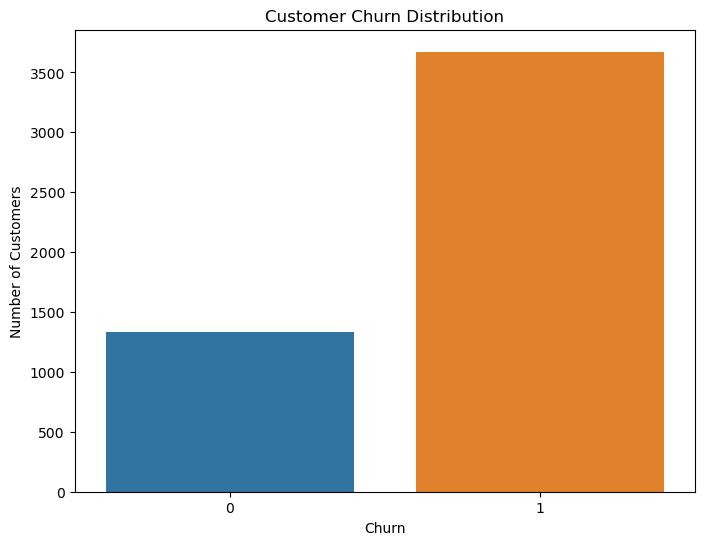

In [137]:
plt.figure(figsize = [8,6])

sns.countplot(data = df, x = 'churn')


plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

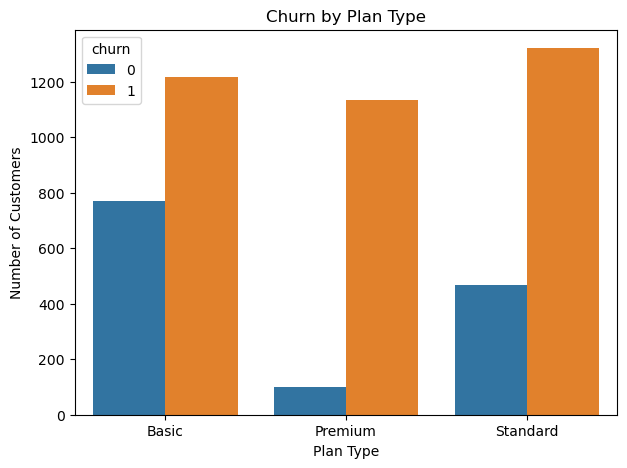

In [138]:
plt.figure(figsize=[7,5])

sns.countplot(data = df, x= "plan_type",hue = "churn")

plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Number of Customers")

plt.show()

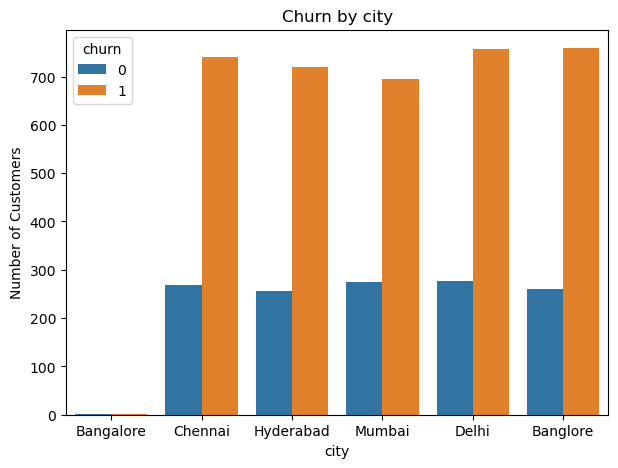

In [139]:
plt.figure(figsize=[7,5])

sns.countplot(data = df, x= "city",hue = "churn")

plt.title("Churn by city")
plt.xlabel("city")
plt.ylabel("Number of Customers")

plt.show()

In [143]:
df["city"].unique()

array(['Bangalore', 'Chennai', 'Hyderabad', 'Mumbai', 'Delhi', 'Banglore'],
      dtype=object)

In [230]:
df["city"] = df["city"].replace("Banglore","Bangalore")

In [231]:
df["city"].unique()

array(['Bangalore', 'Chennai', 'Hyderabad', 'Mumbai', 'Delhi'],
      dtype=object)

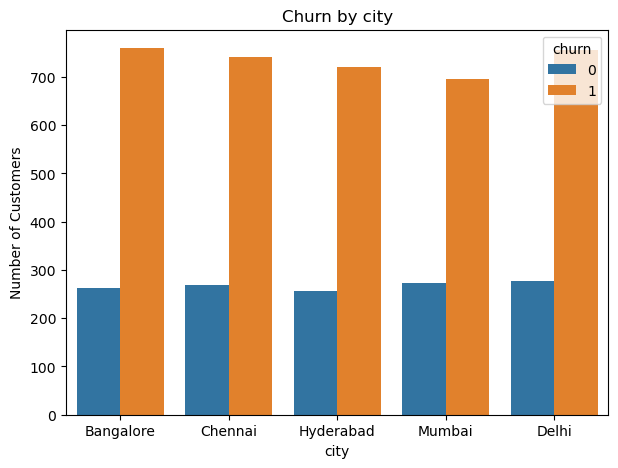

In [146]:
plt.figure(figsize=[7,5])

sns.countplot(data = df, x= "city",hue = "churn")

plt.title("Churn by city")
plt.xlabel("city")
plt.ylabel("Number of Customers")

plt.show()

In [147]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,male,Mumbai,Premium,999.0,48,Credit Card,0


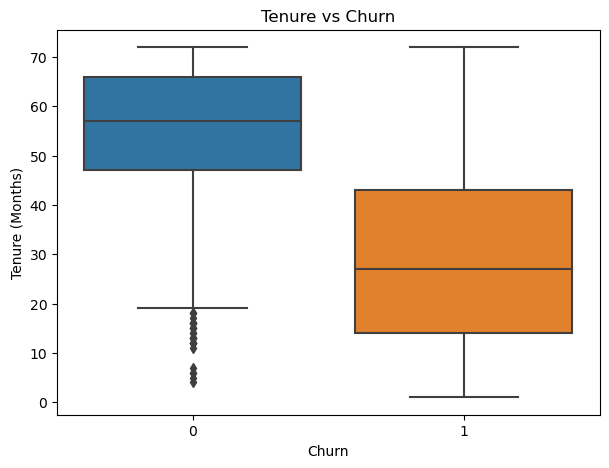

In [148]:
#tenure vs churn

plt.figure (figsize=[7,5])

sns.boxplot(data = df, 
            x= "churn",
           y = "tenure_months")

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Customers who churned generally have lower tenure than customers who remained with the company. The median tenure of churned customers is approximately 27 months, compared with approximately 57 months for retained customers. This indicates that tenure may be an important predictor of churn.

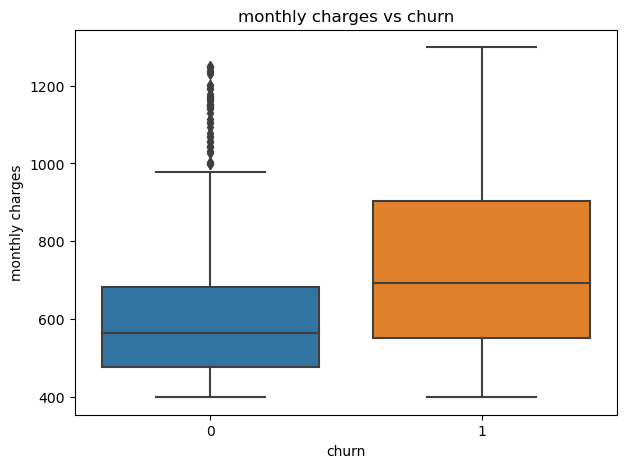

In [149]:
#monthly charges vs churn
plt.figure(figsize = [7,5])

sns.boxplot(x = "churn",
           y = "monthly_charges",
           data = df)

plt.title("monthly charges vs churn")

plt.xlabel("churn")
plt.ylabel("monthly charges")

plt.show();


Customers who churn tend to have higher monthly charges than customers who remain. This suggests that monthly charges may be an important predictor of customer churn

In [151]:
plan_churn = df.groupby("plan_type")["churn"].mean()*100

plan_churn

plan_type
Basic       61.248113
Premium     91.970803
Standard    73.854749
Name: churn, dtype: float64

In [153]:
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [154]:
tenure_churn = (
    df.groupby("tenure_group", observed=True)["churn"]
    .mean() * 100
)

print(tenure_churn)

tenure_group
0-12     98.800959
13-24    95.469989
25-48    79.404617
49-72    42.440801
Name: churn, dtype: float64


The company has a major customer-retention problem among newer customers. Customers who stay longer are significantly less likely to churn.

# Data Preprocessing

In [211]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.0,48,Credit Card,0


In [71]:
X = df[
    [
    "age",
    "gender",
    "city",
    "plan_type",
    "monthly_charges",
    "tenure_months",
    "payment_method"
    ]
]

y = df["churn"]

In [390]:
X.head()

,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method
0,25,Male,Bangalore,Basic,499.0,24,UPI
1,32,Female,Chennai,Premium,999.0,5,Credit Card
2,45,Male,Hyderabad,Standard,699.0,36,UPI
3,29,Female,Bangalore,Basic,499.0,7,Debit Card
4,38,Male,Mumbai,Premium,999.0,48,Credit Card


In [391]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: churn, dtype: int64

In [164]:
X.shape

(5010, 7)

In [165]:
y.shape

(5010,)

In [166]:
df.dtypes

customer_id           int64
customer_name        object
age                   int64
gender               object
city                 object
plan_type            object
monthly_charges     float64
tenure_months         int64
payment_method       object
churn                 int64
tenure_group       category
dtype: object

In [167]:
df.columns

Index(['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type',
       'monthly_charges', 'tenure_months', 'payment_method', 'churn',
       'tenure_group'],
      dtype='object')

In [212]:
df

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.00,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.00,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.00,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.00,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.00,48,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...
5005,6996,Meena,36,female,Chennai,Premium,1016.15,2,UPI,1
5006,6997,Priya,46,female,Banglore,Basic,450.08,60,UPI,0
5007,6998,Arun,37,male,Banglore,Basic,442.36,45,Net banking,1
5008,6999,Arun,46,male,Delhi,Basic,400.23,8,UPI,1


In [215]:
df.isnull().sum()

customer_id           0
customer_name         0
age                4957
gender                0
city                  0
plan_type             0
monthly_charges       0
tenure_months         0
payment_method        0
churn                 0
dtype: int64

In [219]:
df['age'].value_counts().sort_values(ascending = True).head(10)


48    69
60    71
24    72
44    76
33    77
65    77
59    78
63    81
27    83
67    84
Name: age, dtype: int64

In [220]:
df['age'].value_counts().sort_values(ascending = True).index

Int64Index([48, 60, 24, 44, 33, 65, 59, 63, 27, 67, 55, 26, 69, 35, 32, 36, 31,
            18, 19, 47, 37, 20, 56, 30, 22, 23, 70, 57, 58, 29, 28, 41, 53, 61,
            40, 49, 39, 46, 21, 50, 42, 68, 51, 34, 62, 45, 43, 38, 54, 25, 52,
            66, 64],
           dtype='int64')

In [221]:
df['age'].value_counts().sort_values(ascending = True).values

array([ 69,  71,  72,  76,  77,  77,  78,  81,  83,  84,  86,  87,  87,
        88,  90,  91,  91,  91,  93,  93,  93,  93,  93,  93,  93,  94,
        95,  95,  97,  97,  98,  98,  98,  98, 100, 100, 100, 101, 101,
       102, 102, 103, 104, 105, 107, 107, 108, 109, 109, 110, 112, 114,
       116], dtype=int64)

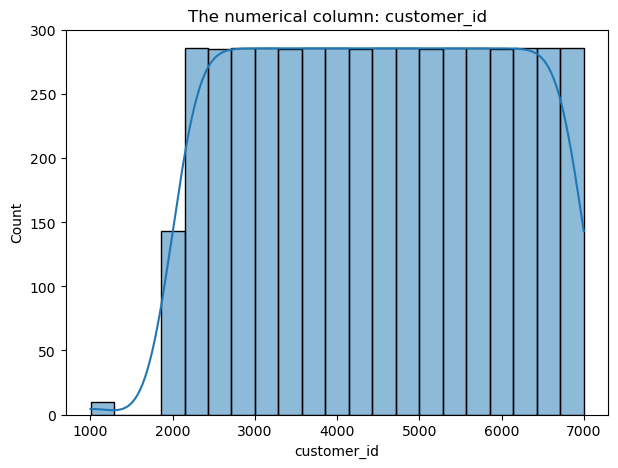

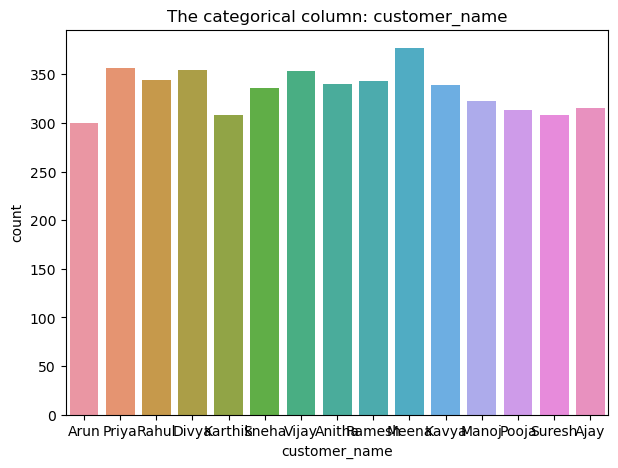

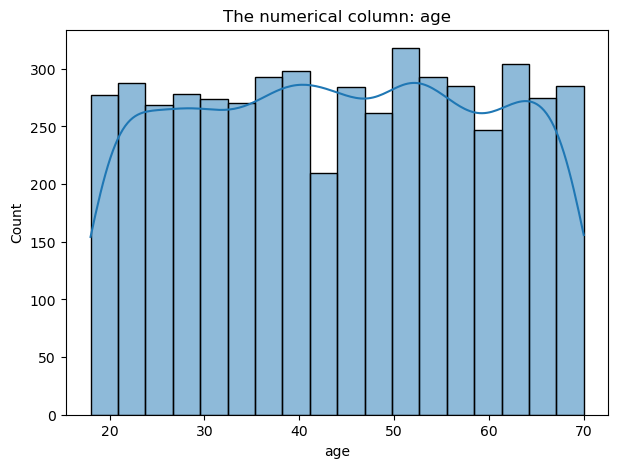

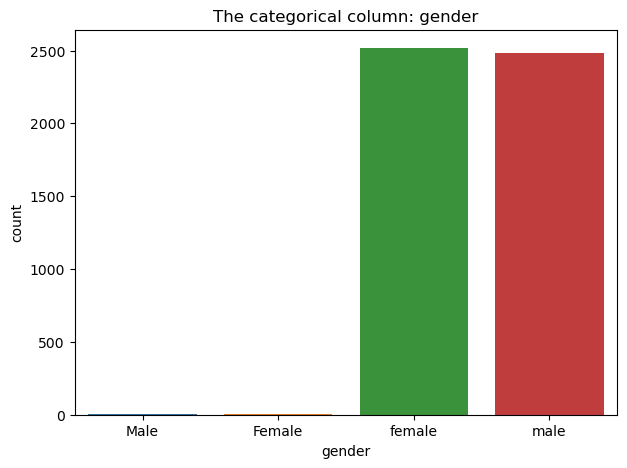

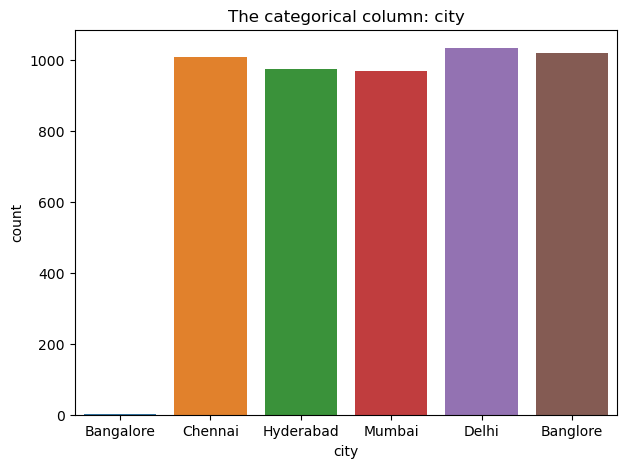

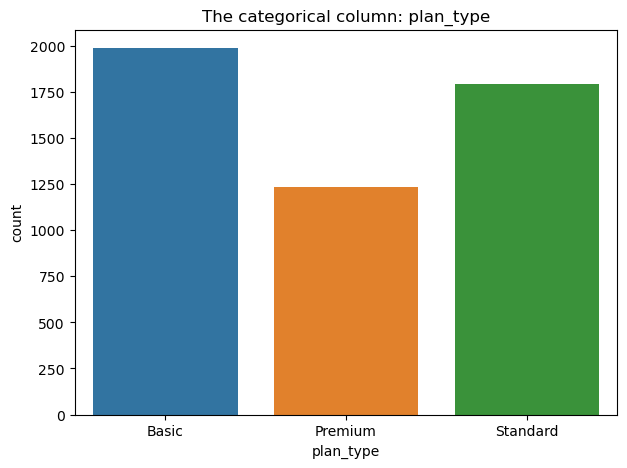

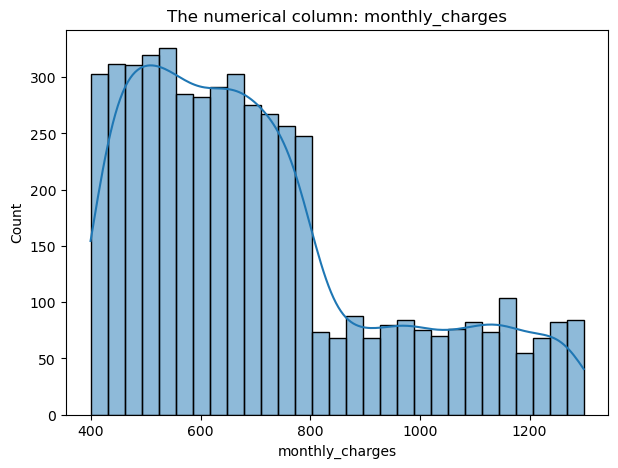

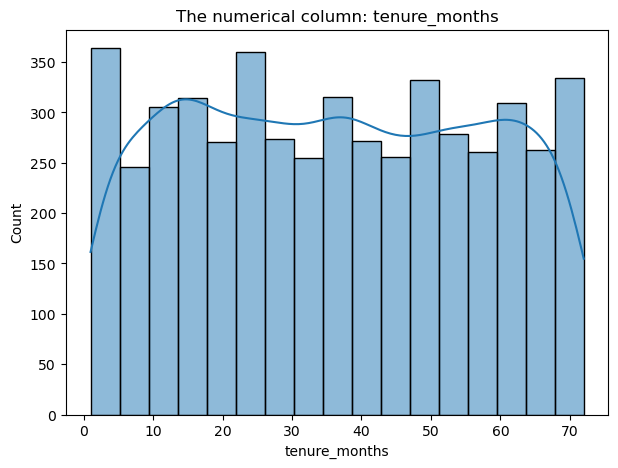

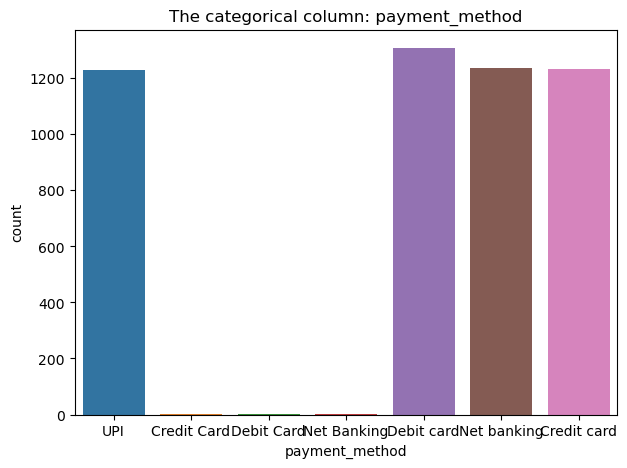

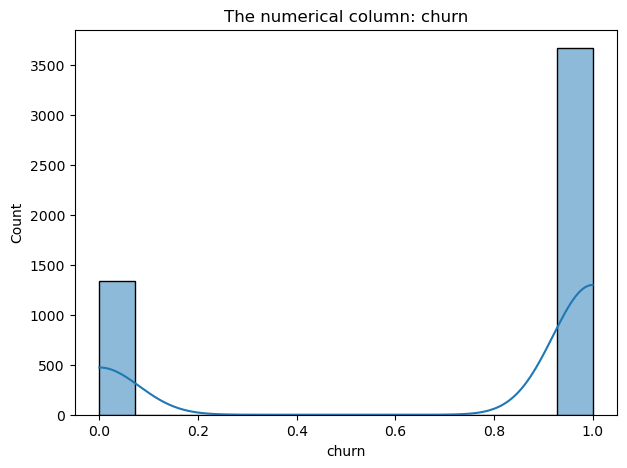

In [70]:
# creating a empty list for num and cat

cat_data= []
num_data =[]

for col in df.columns:
    if df[col].dtypes == "object":
        cat_data.append(col)
        plt.figure(figsize = (7,5))
        sns.countplot(data= df, x = col )
        plt.title(f"The categorical column: {col}")
        plt.show();
        
    else:
        num_data.append(col)
        plt.figure(figsize = (7,5))
        sns.histplot(data = df,x = col, kde= True )
        plt.title(f"The numerical column: {col}")
        plt.show();



In [174]:
#separating numerical columns and categorical columns 

#'''numeric_features =[]

#categorical_features =[]

#for col in df.columns:
 #   if df[col].dtypes == "object":
  #      numeric_features.append(col)
   # else:
    #    categorical_features.append(col)'''

In [66]:
numeric_features

['age', 'monthly_charges', 'tenure_months']

In [67]:
categorical_features

['gender', 'city', 'plan_type', 'payment_method']

In [68]:
numeric_features = [
    "age",
    "monthly_charges",
    "tenure_months"
]

categorical_features = [
    "gender",
    "city",
    "plan_type",
    "payment_method"
]

In [72]:
#train tet split

from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)


In [73]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4008, 7)
(1002, 7)
(4008,)
(1002,)


import standard scaler and onehotencoding to proceed data preprocessing


In [74]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose  import  ColumnTransformer

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#handle_unknown="ignore" -- This protects us if a new customer during deployment-
#-has a category that wasn't present in the training data.

In [76]:
X_train_processed = preprocessor.fit_transform(X_train)

In [77]:
X_test_processed = preprocessor.transform(X_test)

In [78]:
print("Before preprocessing:", X_train.shape)
print("After preprocessing :", X_train_processed.shape)

Before preprocessing: (4008, 7)
After preprocessing : (4008, 23)


In [79]:
X_train_processed.shape

(4008, 23)

In [80]:
X_test_processed.shape

(1002, 23)

In [81]:
X["age"].isna().sum()

0

In [206]:
df['age'].isna().sum()

4978

In [82]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(age) AS non_null_age
FROM customers
"""

pd.read_sql_query(query, conn)

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\1189397582.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(query, conn)


,total_rows,non_null_age
0,5010,5010


In [83]:
query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.age,
    c.gender,
    c.city,
    s.plan_type,
    s.monthly_charges,
    s.tenure_months,
    p.payment_method,
    c.churn
FROM customers c
INNER JOIN subscriptions s
    ON c.customer_id = s.customer_id
INNER JOIN payments p
    ON c.customer_id = p.customer_id;
"""

df = pd.read_sql_query(query, conn)

C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\3393553329.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [217]:
df["age"].isnull().sum()

0

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

In [237]:
query = "Select * from customers"

df = pd.read_sql_query(query,conn)

df.head()

C:\Users\Win10\AppData\Local\Temp\ipykernel_8888\820829142.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query,conn)


,customer_id,customer_name,age,gender,city,churn
0,1001,Arun,25,Male,Bangalore,0
1,1002,Priya,32,Female,Chennai,1
2,1003,Rahul,45,Male,Hyderabad,0
3,1004,Divya,29,Female,Bangalore,1
4,1005,Karthik,38,Male,Mumbai,0


# Logistic Regression

In [88]:
model = LogisticRegression()

In [89]:
model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [90]:
y_pred = model.predict(X_test_processed)

In [91]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy score is: ",accuracy)

Accuracy score is:  0.8273453093812375


In [92]:
y_pred_train = model.predict(X_train_processed)

In [93]:
accuracy_train = accuracy_score(y_pred_train, y_train)

print("Accuracy score is: ",accuracy_train)

Accuracy score is:  0.8390718562874252


In [94]:
accuracy_table = pd.DataFrame({"accuracy on train data":[accuracy_train],
                               "accuracy on test data":[accuracy]}
                             )
accuracy_table

,accuracy on train data,accuracy on test data
0,0.839072,0.827345


In [95]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8556962025316456


In [96]:
recall = recall_score (y_test,y_pred)

print("Recall score",recall)

Recall score 0.9197278911564626


In [97]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8865573770491804


In [98]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[153 114]
 [ 59 676]]


In [99]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.57      0.64       267
           1       0.86      0.92      0.89       735

    accuracy                           0.83      1002
   macro avg       0.79      0.75      0.76      1002
weighted avg       0.82      0.83      0.82      1002



In [100]:
model = LogisticRegression()

model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [101]:
y_pred = model.predict(X_test_processed)

print(y_pred)

[1 0 1 ... 1 1 1]


In [102]:
LR_score_report = pd.DataFrame({"Metric":["accuracy_train","accuracy_test","precision score","recall_score","f1 score"],
                               "Score":[accuracy_train,accuracy,precision,recall,f1]
                               }
                              )
LR_score_report

,Metric,Score
0,accuracy_train,0.839072
1,accuracy_test,0.827345
2,precision score,0.855696
3,recall_score,0.919728
4,f1 score,0.886557


# Decision Tree

In [103]:
from sklearn.tree import DecisionTreeClassifier

In [104]:
dt_model = DecisionTreeClassifier(random_state =42)

In [105]:
dt_model.fit(X_train_processed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [106]:
y_pred_dt = dt_model.predict(X_test_processed)


In [107]:
y_pred_dt_score= accuracy_score(y_test,y_pred_dt)
y_pred_dt_score

0.7614770459081837

In [108]:
y_pred_dt_train = dt_model.predict(X_train_processed)


In [109]:
y_pred_dt_train_score= accuracy_score(y_train,y_pred_dt_train)
y_pred_dt_train_score

1.0

In [110]:
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree")
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree
Precision: 0.8360433604336044
Recall   : 0.8394557823129252
F1 Score : 0.8377460964019009


In [111]:
DT_score_report = pd.DataFrame({"Metric":["DT_train","DT_accuracy_test","DT_precision score","DT_recall_score","DT_f1 score"],
                               "Score":[y_pred_dt_train_score,y_pred_dt_score,precision_dt,recall_dt,f1_dt]
                               }
                              )
DT_score_report

,Metric,Score
0,DT_train,1.000000
1,DT_accuracy_test,0.761477
2,DT_precision score,0.836043
3,DT_recall_score,0.839456
4,DT_f1 score,0.837746


# Random forest

In [112]:
from sklearn.ensemble import RandomForestClassifier

In [113]:
rf_model = RandomForestClassifier(random_state = 42)

In [114]:
rf_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
rf_model_pred = rf_model.predict(X_test_processed)

In [116]:
rf_model_train_pred = rf_model.predict(X_train_processed)

In [117]:
rf_model_pred_score = accuracy_score(y_test,rf_model_pred)
rf_model_train_pred_score = accuracy_score(y_train,rf_model_train_pred)
rf_precision = precision_score(y_test,rf_model_pred)
rf_recall = recall_score(y_test,rf_model_pred)
rf_f1 = f1_score(y_test,rf_model_pred)

print("RF Test Accuracy :", rf_model_pred_score)
print("RF Train Accuracy  :", rf_model_train_pred_score)
print("RF Precision      :", rf_precision)
print("RF Recall         :", rf_recall)
print("RF F1 Score       :", rf_f1)

RF Test Accuracy : 0.8073852295409182
RF Train Accuracy  : 1.0
RF Precision      : 0.8430379746835444
RF Recall         : 0.9061224489795918
RF F1 Score       : 0.8734426229508196


In [118]:
rf_confusion = confusion_matrix(y_test,rf_model_pred)
rf_confusion

array([[143, 124],
       [ 69, 666]], dtype=int64)

In [119]:
print(classification_report(y_test, rf_model_pred))

              precision    recall  f1-score   support

           0       0.67      0.54      0.60       267
           1       0.84      0.91      0.87       735

    accuracy                           0.81      1002
   macro avg       0.76      0.72      0.74      1002
weighted avg       0.80      0.81      0.80      1002



# KNN model 
#### K-Nearest Neighbors

In [120]:
from sklearn.neighbors import KNeighborsClassifier

In [121]:
knn_model = KNeighborsClassifier(n_neighbors = 5)

In [122]:
knn_model.fit(X_train_processed, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [123]:
y_pred_knn = knn_model.predict(X_test_processed)

In [124]:
y_pred_train_knn = knn_model.predict(X_train_processed)

In [125]:
y_pred_knn_score = accuracy_score(y_test,y_pred_knn)
y_pred_train_knn_score = accuracy_score(y_train,y_pred_train_knn)
knn_precison = precision_score(y_test,y_pred_knn)
knn_recall = recall_score(y_test,y_pred_knn)
knn_f1 = f1_score(y_test,y_pred_knn)

print("KNN Score Report")
print("KNN test accuracy: ",y_pred_knn_score*100)
print("KNN train accuracy: ",y_pred_train_knn_score*100)
print("KNN precision accuracy: ",knn_precison*100)
print("KNN Recall accuracy: ",knn_recall*100)
print("KNN f1 accuracy: ",knn_f1*100)

KNN Score Report
KNN test accuracy:  81.0379241516966
KNN train accuracy:  85.77844311377245
KNN precision accuracy:  84.89116517285531
KNN Recall accuracy:  90.20408163265307
KNN f1 accuracy:  87.46701846965699


In [126]:
knn_cm  = confusion_matrix(y_test,y_pred_knn)
confusion_matrix
print(knn_cm)

[[149 118]
 [ 72 663]]


In [127]:
print(classification_report (y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.67      0.56      0.61       267
           1       0.85      0.90      0.87       735

    accuracy                           0.81      1002
   macro avg       0.76      0.73      0.74      1002
weighted avg       0.80      0.81      0.80      1002



# SVM

In [128]:
from sklearn.svm import SVC

In [129]:
svm_model = SVC()

In [130]:
svm_model.fit(X_train_processed,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [131]:
svm_y_pred = svm_model.predict(X_test_processed)

In [132]:
svm_y_train_pred = svm_model.predict(X_train_processed)

In [133]:
svm_y_pred_score = accuracy_score(y_test,svm_y_pred)
svm_train_pred_score = accuracy_score(y_train,svm_y_train_pred)
svm_precision = precision_score(y_test,svm_y_pred)
svm_recall = recall_score(y_test,svm_y_pred)
svm_f1 = f1_score(y_test,svm_y_pred)

print("Support vector Machine")
print("Accuracy test score: ",svm_y_pred_score)
print("Accuracy train score: ",svm_train_pred_score)
print("Precison score: ",svm_precision)
print("Recall score: ",svm_recall)
print("F1 score: ",svm_f1)

Support vector Machine
Accuracy test score:  0.8323353293413174
Accuracy train score:  0.845558882235529
Precison score:  0.8611464968152867
Recall score:  0.9197278911564626
F1 score:  0.8894736842105263


In [134]:
cm_svm = confusion_matrix(y_test, svm_y_pred)

print(cm_svm)

[[158 109]
 [ 59 676]]


# Gradient Boosting

In [135]:
from sklearn.ensemble import GradientBoostingClassifier

In [136]:
gb_model = GradientBoostingClassifier()

In [137]:
gb_model.fit(X_train_processed,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [138]:
gb_y_pred = gb_model.predict(X_test_processed)

In [139]:
gb_train_pred = gb_model.predict(X_train_processed)

In [140]:
gb_y_pred_score = accuracy_score(y_test,gb_y_pred)
gb_train_pred_score = accuracy_score(y_train,gb_train_pred)
gb_precision = precision_score(y_test,gb_y_pred)
gb_recall = recall_score(y_test,gb_y_pred)
gb_f1 = f1_score(y_test,gb_y_pred)

print("Gradient Boosting Model")
print("Accuracy test score: ",gb_y_pred_score)
print("Accuracy Train score: ",gb_train_pred_score)
print("Precision score: ",gb_precision)
print("Recall score: ",gb_recall)
print("F1 score: ",gb_f1)

Gradient Boosting Model
Accuracy test score:  0.8173652694610778
Accuracy Train score:  0.8570359281437125
Precision score:  0.860313315926893
Recall score:  0.8965986394557823
F1 score:  0.8780812791472352


In [141]:
gb_cm = confusion_matrix(y_test,gb_y_pred)
gb_cm

array([[160, 107],
       [ 76, 659]], dtype=int64)

In [142]:
print((gb_train_pred_score - gb_y_pred_score)*100)

3.967065868263475


In [143]:
final_model_report=pd.DataFrame({
    "Model_name":["LogisticRegression",
                  "DecisionTreeClassifier",
                  "RandomForestClassifier",
                  "KNeighborsClassifier",
                  "Support vector Classifier",
                  "GradientBoostingClassifier"],
    "Training Score":[accuracy_train,
                      y_pred_dt_train_score,
                      rf_model_train_pred_score,
                      y_pred_train_knn_score,
                      svm_train_pred_score,
                      gb_train_pred_score],
    "Testing Score":[accuracy,
                     y_pred_dt_score,
                     rf_model_pred_score,
                     y_pred_knn_score,
                     svm_y_pred_score,
                     gb_y_pred_score],
    "difference":[((accuracy_train-accuracy)*100),
                  ((y_pred_dt_train_score-y_pred_dt_score)*100),
                  ((rf_model_train_pred_score-rf_model_pred_score)*100),
                  ((y_pred_train_knn_score-y_pred_knn_score)*100),
                  ((svm_train_pred_score - svm_y_pred_score)*100),
                  ((gb_train_pred_score-gb_y_pred_score)*100)]
})

final_model_report

,Model_name,Training Score,Testing Score,difference
0,LogisticRegression,0.839072,0.827345,1.172655
1,DecisionTreeClassifier,1.000000,0.761477,23.852295
2,RandomForestClassifier,1.000000,0.807385,19.261477
3,KNeighborsClassifier,0.857784,0.810379,4.740519
4,Support vector Classifier,0.845559,0.832335,1.322355
5,GradientBoostingClassifier,0.857036,0.817365,3.967066


- After comparing all the model scores. SVM performed well, 
- train score - 84% and test score -83%
- will perform Hyperparameter tunning on SVM model.

# importing gridsearch parameter


In [322]:
from sklearn.model_selection import GridSearchCV

In [323]:
param_grid = {
    "C": [0.1,1,10,100],
    "kernel":['linear','rbf'],
    "gamma":['sclae','auto']
}

In [325]:
grid_search = GridSearchCV(
    estimator = svm_model,
    param_grid =param_grid,
    scoring = 'f1',
    n_jobs = -1,
    cv=5
)

In [327]:
grid_search.fit(X_train_processed,y_train)

D:\ProgramData\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
32 fits failed with the following error:
Traceback (most recent call last):
  File "D:\ProgramData\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py", line 180, in fit
    self._validate_params()
  File "D:\ProgramData\anaconda3\lib\site-packages\sklearn\base.py", line 581, in _validate_params
    validate_parameter_constraints(
  File "D:\ProgramData\anaconda3\lib\site-packages\sklea

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['sclae', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [332]:
print("Best Parameters")
print(grid_search.best_params_)
#best parameters

Best Parameters
{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [333]:
print("best cv f1 score")
print(grid_search.best_score_)
#This tells us the best average F1 score obtained during cross-validation.

best cv f1 score
0.890107802688236


In [334]:
best_svm_gs = grid_search.best_estimator_

In [335]:
best_svm_gs

SVC(C=1, gamma='auto')

In [336]:
y_pred_svm_tunned = grid_search.predict(X_test_processed)

In [338]:
tuned_accuracy = accuracy_score(y_test, y_pred_svm_tunned)
tuned_precision = precision_score(y_test, y_pred_svm_tunned)
tuned_recall = recall_score(y_test, y_pred_svm_tunned)
tuned_f1 = f1_score(y_test, y_pred_svm_tunned)

print("Tuned SVM Accuracy :", tuned_accuracy)
print("Tuned SVM Precision:", tuned_precision)
print("Tuned SVM Recall   :", tuned_recall)
print("Tuned SVM F1       :", tuned_f1)

Tuned SVM Accuracy : 0.8253493013972056
Tuned SVM Precision: 0.8544303797468354
Tuned SVM Recall   : 0.9183673469387755
Tuned SVM F1       : 0.8852459016393444


In [339]:
print(confusion_matrix(y_test, y_pred_svm_tunned))

[[152 115]
 [ 60 675]]


tuning did not improve our SVM on the test set.

GridSearchCV found the best parameters according to the cross-validation score on the training data. That doesn't guarantee that those parameters will beat the original default model on this particular held-out test set.

In [144]:
from sklearn.pipeline import Pipeline

In [145]:
#we need to make sure the same preprocessing is applied to new customers before prediction.
final_pipeline  =Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

In [146]:
final_pipeline 

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [147]:
import joblib

In [148]:
# Train the complete pipeline
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [149]:
#Test the pipeline
y_pred_final = final_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Accuracy: 0.8323353293413174
Precision: 0.8611464968152867
Recall: 0.9197278911564626
F1 Score: 0.8894736842105263


In [168]:
joblib.dump(final_pipeline, "customer_churn_pipeline.pkl")

['customer_churn_pipeline.pkl']

In [151]:
#checking the file exist or not
import os

print(os.path.exists("customer_churn_pipeline.pkl"))

True


In [152]:
#load_the saved model
loaded_pipeline = joblib.load("customer_churn_pipeline.pkl")

In [153]:
new_customer = pd.DataFrame({
    "age": [35],
    "monthly_charges": [75.5],
    "tenure_months": [12],
    "gender": ["Male"],
    "city": ["Bangalore"],
    "plan_type": ["Premium"],
    "payment_method": ["Credit Card"]
})

In [154]:
prediction = loaded_pipeline.predict(new_customer)
print(prediction)

[1]


In [155]:
print(df.columns.tolist())

['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type', 'monthly_charges', 'tenure_months', 'payment_method', 'churn']


In [156]:
print(df.columns.tolist())

['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type', 'monthly_charges', 'tenure_months', 'payment_method', 'churn']


In [157]:
df.columns

Index(['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type',
       'monthly_charges', 'tenure_months', 'payment_method', 'churn'],
      dtype='object')

In [158]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.0,48,Credit Card,0


In [159]:
new_customer1 = pd.DataFrame({
    "age": [45],
    "monthly_charges": [49.0],
    "tenure_months": [48],
    "gender": ["Male"],
    "city": ["Bangalore"],
    "plan_type": ["Basic"],
    "payment_method": ["UPI"]
})

prediction = loaded_pipeline.predict(new_customer1)

print(prediction)

[0]


In [160]:
print(df.columns.tolist())
print(df.shape)

['customer_id', 'customer_name', 'age', 'gender', 'city', 'plan_type', 'monthly_charges', 'tenure_months', 'payment_method', 'churn']
(5010, 10)


In [161]:
df.head()

,customer_id,customer_name,age,gender,city,plan_type,monthly_charges,tenure_months,payment_method,churn
0,1001,Arun,25,Male,Bangalore,Basic,499.0,24,UPI,0
1,1002,Priya,32,Female,Chennai,Premium,999.0,5,Credit Card,1
2,1003,Rahul,45,Male,Hyderabad,Standard,699.0,36,UPI,0
3,1004,Divya,29,Female,Bangalore,Basic,499.0,7,Debit Card,1
4,1005,Karthik,38,Male,Mumbai,Premium,999.0,48,Credit Card,0


In [162]:
query = "SELECT * FROM customers"

df = pd.read_sql_query(query, conn)

print(df.columns.tolist())
print(df.shape)

['customer_id', 'customer_name', 'age', 'gender', 'city', 'churn']
(5010, 6)


C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\13351890.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [163]:
tables = pd.read_sql_query("""
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE'
""", conn)

print(tables)

      TABLE_NAME
0      customers
1  subscriptions
2       payments


C:\Users\Win10\AppData\Local\Temp\ipykernel_27552\1995188021.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql_query("""


In [374]:
columns = pd.read_sql_query("""
SELECT TABLE_NAME, COLUMN_NAME
FROM INFORMATION_SCHEMA.COLUMNS
ORDER BY TABLE_NAME, ORDINAL_POSITION
""", conn)

print(columns)

       TABLE_NAME      COLUMN_NAME
0       customers      customer_id
1       customers    customer_name
2       customers              age
3       customers           gender
4       customers             city
5       customers            churn
6        payments       payment_id
7        payments      customer_id
8        payments   payment_method
9   subscriptions   subcription_id
10  subscriptions      customer_id
11  subscriptions        plan_type
12  subscriptions  monthly_charges
13  subscriptions    tenure_months


C:\Users\Win10\AppData\Local\Temp\ipykernel_8888\3538398278.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  columns = pd.read_sql_query("""


In [403]:
import sklearn
print(sklearn.__version__)

1.2.1


In [ ]:
!pip install --upgrade scikit-learn

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"

)

#custom CSS

st.markdown("""
<style>

.stApp {
    background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
}

/* Main container */
.block-container {
    padding-top: 2rem;
    padding-bottom: 2rem;
}

/* Title */
.main-title {
    text-align: center;
    color: white;
    font-size: 42px;
    font-weight: 700;
    margin-bottom: 5px;
}

/* Subtitle */
.subtitle {
    text-align: center;
    color: #d6e4ea;
    font-size: 18px;
    margin-bottom: 35px;
}

/* Section title */
.section-title {
    color: white;
    font-size: 24px;
    font-weight: 600;
    margin-top: 10px;
    margin-bottom: 15px;
}

/* Input labels */
label {
    color: white !important;
    font-weight: 600 !important;
}

/* Text input */
.stTextInput input,
.stNumberInput input {
    border-radius: 8px;
}

/* Select boxes */
.stSelectbox > div > div {
    border-radius: 8px;
}

/* Predict button */
.stButton > button {
    width: 100%;
    height: 55px;
    background: #00c853;
    color: white;
    font-size: 20px;
    font-weight: 700;
    border: none;
    border-radius: 10px;
    margin-top: 20px;
}

.stButton > button:hover {
    background: #00a844;
    color: white;
}

/* Result card */
.result-card {
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    background: rgba(255,255,255,0.12);
    border: 1px solid rgba(255,255,255,0.2);
    margin-top: 25px;
}

/* Result text */
.result-title {
    color: white;
    font-size: 28px;
    font-weight: 700;
}

.result-description {
    color: #d6e4ea;
    font-size: 17px;
}

/* Footer */
.footer {
    text-align: center;
    color: #b8cbd2;
    font-size: 14px;
    margin-top: 40px;
}

</style>
""", unsafe_allow_html=True)



#load saved model

model = joblib.load("customer_churn_pipeline.pkl")


st.title("📊 Customer Churn Prediction.")

st.write("Enter the customer details below to predict whether "
    "the customer is likely to churn or not.")

# Customer Input

age = st.number_input(
    "Age",
    min_value =18,
    max_value = 100,
    value = 35
)

monthly_charges = st.number_input(
    "Monthly Charges",
    min_value = 0.0,
    value = 499.0,
    step = 1.0

)

tenure_months = st.number_input(
    "Tenure Month",
    min_value = 0,
    max_value = 120,
    value = 12
)

gender = st.selectbox(
    "Gender",
    ["Male","Female"]
)

city = st.text_input(
    "City",
    placeholder = "Enter city name"
)

plan_type = st.selectbox(
    "Plan Type",
    ["Basic", "Standard", "Premium"]
)

payment_method = st.selectbox(
    "Payment Method",
    ["UPI", "Credit Card", "Debit Card"]
)

if st.button("Predict Churn"):

    #error for city if empty

    if city.strip() =="":
        st.warning("please enter the City name")
    else:
        new_customer = pd.DataFrame(
            {
            "age":[age],
            "monthly_charges":[monthly_charges],
            "tenure_months":[tenure_months],
            "gender":[gender],
            "city":[city],
            "plan_type":[plan_type],
            "payment_method":[payment_method]
            }
        )

        #prediction
        prediction = model.predict(new_customer)


        #Display  result

        if prediction[0] == 1:
            st.error(
                "Customer is  likely to Churn"
            )
        else:
            st.success(
                "Custormer is not likely to  churn"
            )


